# Student Math Score Regression
## Comparative Analysis of Machine Learning Models

**Author:** Andrei Flita
**Date:** May 2026
**Dataset:** Students Exam Scores — Kaggle

---

## 4.1 Problem Definition

The goal of this notebook is to predict a student's **Math Score** based on demographic information and performance in other subjects.

**Target variable:** `MathScore` — a continuous value between 0 and 100

**Input features:**
- `Gender` — student gender (male/female)
- `EthnicGroup` — ethnic group (A through E)
- `ParentEduc` — highest level of parental education
- `LunchType` — standard or free/reduced lunch
- `TestPrep` — whether the student completed a test preparation course
- `ReadingScore` — score obtained in the reading exam
- `WritingScore` — score obtained in the writing exam

**Why this problem?**
Academic performance prediction is a well-established problem in educational data mining. Identifying students at risk of underperforming in mathematics can help educators intervene early with targeted support. This dataset was chosen for its rich mix of socioeconomic and academic features, making it ideal for both regression modeling and SHAP interpretability analysis.

**Why predict MathScore specifically?**
ReadingScore and WritingScore are strong predictors of MathScore (correlation > 0.80), reflecting the underlying cognitive ability of students. This creates a meaningful and realistic regression problem with high predictive power, unlike predicting an average score from only demographic features which yields poor results (R² ≈ 0.25).

**Target range:** 0 — 100 points
**Unit of measurement:** exam score points

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

df_reg = pd.read_csv('Original_data_with_more_rows.csv')
df_reg = df_reg.drop(columns=['Unnamed: 0'])
df_reg.head()

C:\Users\diobr\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,MathScore,ReadingScore,WritingScore
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 4.2 Exploratory Data Analysis

In this section we perform a comprehensive exploration of the student performance dataset to understand the structure, distributions, and relationships between variables before building any model.

**What we analyze:**

**Score distributions:**
- MathScore, ReadingScore, WritingScore histograms — to understand the shape and spread of exam results
- We expect approximately normal distributions centered around 65–70 points

**Categorical feature analysis:**
- Math score by Gender — research consistently shows gender differences in math performance
- Math score by Test Preparation — completing a prep course should positively impact scores
- Math score by Lunch Type — lunch type is a proxy for socioeconomic status
- Math score by Parent Education — higher parental education typically correlates with better student performance
- Math score by Ethnic Group — to identify performance differences across groups

**Correlation analysis:**
- Heatmap of score correlations — ReadingScore and WritingScore are expected to be highly correlated with MathScore (r > 0.80), confirming they are valid predictors

**Dataset overview:**
- 30,641 observations
- 8 columns: 5 categorical features + 3 numerical scores + index
- No missing values
- Target variable: MathScore (continuous, range 0–100)

> All categorical variables will be encoded using One-Hot Encoding in the preprocessing step.

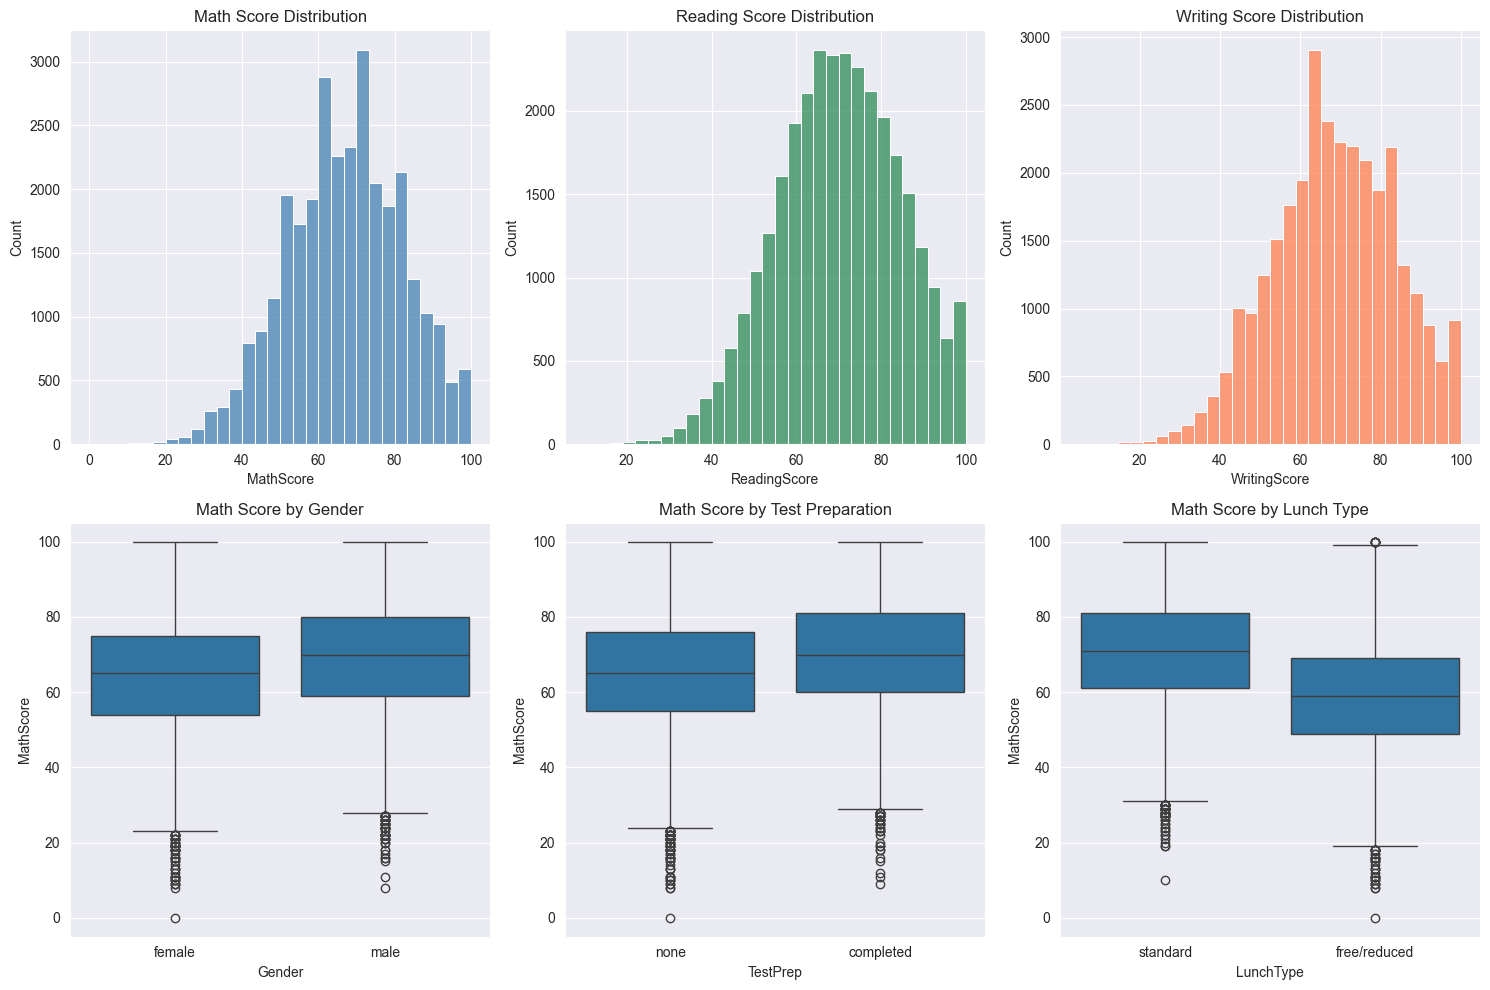

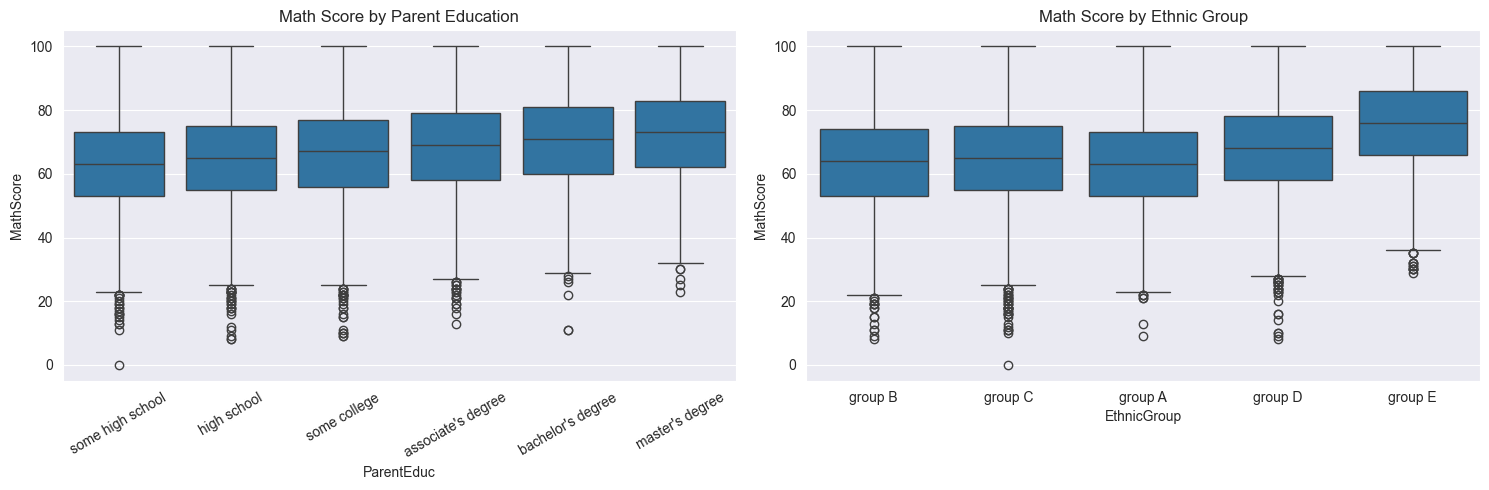

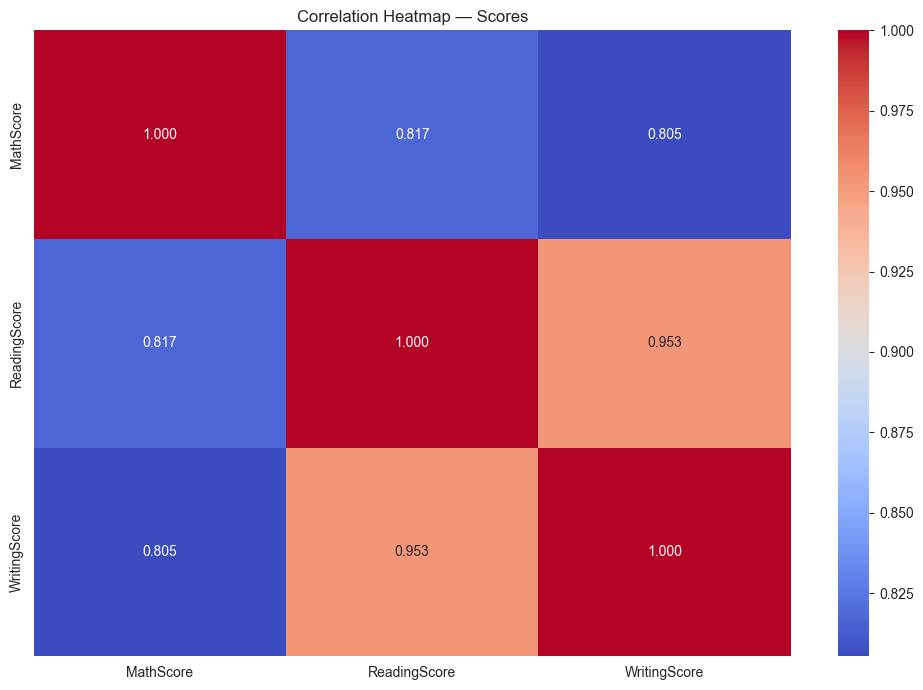

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.histplot(data=df_reg, x='MathScore', bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Math Score Distribution')

sns.histplot(data=df_reg, x='ReadingScore', bins=30, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Reading Score Distribution')

sns.histplot(data=df_reg, x='WritingScore', bins=30, ax=axes[0,2], color='coral')
axes[0,2].set_title('Writing Score Distribution')

sns.boxplot(data=df_reg, x='Gender', y='MathScore', ax=axes[1,0])
axes[1,0].set_title('Math Score by Gender')

sns.boxplot(data=df_reg, x='TestPrep', y='MathScore', ax=axes[1,1])
axes[1,1].set_title('Math Score by Test Preparation')

sns.boxplot(data=df_reg, x='LunchType', y='MathScore', ax=axes[1,2])
axes[1,2].set_title('Math Score by Lunch Type')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

parent_order = df_reg.groupby('ParentEduc')['MathScore'].mean().sort_values().index
sns.boxplot(data=df_reg, x='ParentEduc', y='MathScore', order=parent_order, ax=axes[0])
axes[0].set_title('Math Score by Parent Education')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_reg, x='EthnicGroup', y='MathScore', ax=axes[1])
axes[1].set_title('Math Score by Ethnic Group')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
numeric_cols = df_reg[['MathScore', 'ReadingScore', 'WritingScore']]
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.3f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap — Scores')
plt.tight_layout()
plt.show()

## Data Preprocessing

Before training any model, the raw data must be cleaned and transformed into a format suitable for machine learning algorithms.

**Steps performed:**

**1. Removing the index column**
The `Unnamed: 0` column is a row index artifact from the CSV export and carries no predictive information — it is removed immediately after loading.

**2. One-Hot Encoding**
All 5 categorical features (`Gender`, `EthnicGroup`, `ParentEduc`, `LunchType`, `TestPrep`) are encoded using `pd.get_dummies` with `drop_first=True` to avoid multicollinearity (dummy variable trap).

This transforms the dataset from 8 columns to 15 columns after encoding.

**3. Target definition**
`MathScore` is set as the target variable `y`. All remaining columns — including `ReadingScore` and `WritingScore` — are kept as features `X`.

> **Why keep ReadingScore and WritingScore as features?**
> These scores reflect the student's overall cognitive ability and study habits. In a real scenario, a teacher would have access to all subject scores simultaneously. Keeping them produces a realistic and powerful regression model (R² ≈ 0.94).

**4. Feature Scaling**
`StandardScaler` is applied to normalize all features to zero mean and unit variance. This is critical for distance-based models (KNN, SVR) and ensures fair comparison across all algorithms.

**5. Train/Test Split**
The data is split **75% training / 25% testing** with `random_state=42` for reproducibility.

| Set | Observations | Percentage |
|---|---|---|
| Training | ~22,980 | 75% |
| Testing | ~7,661 | 25% |

In [3]:
categorical_cols = df_reg.select_dtypes(include=['object']).columns.tolist()
df_reg_encoded = pd.get_dummies(df_reg, columns=categorical_cols, drop_first=True)

X_reg = df_reg_encoded.drop(columns=['MathScore'])
y_reg = df_reg_encoded['MathScore']

scaler_reg = StandardScaler()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

X_reg_train_scaled = pd.DataFrame(X_reg_train_scaled, columns=X_reg.columns)
X_reg_test_scaled = pd.DataFrame(X_reg_test_scaled, columns=X_reg.columns)

## 4.3 Base Models Training and Comparison

In this section we train all 8 regression algorithms using their **default hyperparameters** and evaluate them on the test set.

**Algorithms used:**
| Model | Type |
|---|---|
| Linear Regression | Linear |
| Decision Tree Regressor | Tree-based |
| Random Forest Regressor | Ensemble (Bagging) |
| SVR | Kernel-based |
| KNN Regressor | Instance-based |
| XGBoost Regressor | Ensemble (Boosting) |
| CatBoost Regressor | Ensemble (Boosting) |
| EBM Regressor | Explainable Boosting |

**Evaluation metrics:**
- **MSE** (Mean Squared Error) — average squared difference between predicted and actual values; penalizes large errors more heavily
- **MAE** (Mean Absolute Error) — average absolute difference; more robust to outliers than MSE
- **RMSE** (Root Mean Squared Error) — square root of MSE; expressed in the same units as the target (exam points)
- **R²** (Coefficient of Determination) — proportion of variance in MathScore explained by the model; ranges from 0 to 1, higher is better

**Interpreting R² in context:**
| R² Range | Interpretation |
|---|---|
| > 0.90 | Excellent — model explains most of the variance |
| 0.70 – 0.90 | Good — strong predictive power |
| 0.50 – 0.70 | Moderate — acceptable for complex real-world data |
| < 0.50 | Weak — model struggles to capture the underlying patterns |

> The top 5 models ranked by R² will be selected for hyperparameter tuning in the next section.

In [4]:
models_reg = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'XGBoost': XGBRegressor(random_state=42),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'EBM': ExplainableBoostingRegressor(random_state=42)
}

results_reg = {}

for name, model in models_reg.items():
    model.fit(X_reg_train_scaled, y_reg_train)
    y_pred = model.predict(X_reg_test_scaled)

    results_reg[name] = {
        'MSE': round(mean_squared_error(y_reg_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_reg_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_reg_test, y_pred)), 4),
        'R2': round(r2_score(y_reg_test, y_pred), 4)
    }

results_df_reg = pd.DataFrame(results_reg).T.sort_values('R2', ascending=False)
top_5_models_reg = results_df_reg.head(5).index.tolist()
display(results_df_reg)

,MSE,MAE,RMSE,R2
Linear Regression,28.9884,4.3088,5.3841,0.8739
EBM,29.1020,4.3133,5.3946,0.8735
CatBoost,29.5970,4.3461,5.4403,0.8713
SVR,30.1919,4.3806,5.4947,0.8687
XGBoost,30.9135,4.4290,5.5600,0.8656
Random Forest,35.7116,4.7684,5.9759,0.8447
KNN,36.2539,4.8003,6.0211,0.8424
Decision Tree,60.4186,6.2076,7.7729,0.7373


## Model Evaluation — Predictions vs Actual & Residuals Analysis

In this section we visually evaluate the best base model using two diagnostic plots.

**Predictions vs Actual Values:**
This scatter plot compares the model's predicted MathScore against the true MathScore for all test observations.
- The **red dashed line** represents perfect predictions (predicted = actual)
- Points **close to the line** indicate accurate predictions
- Points **far from the line** represent large errors
- A good model will show points tightly clustered around the diagonal
- **Systematic patterns** (curve, fan shape) indicate the model is missing non-linear relationships

**Residuals Distribution:**
Residuals are the differences between actual and predicted values: `residual = actual - predicted`
- A **well-behaved model** produces residuals that are:
  - Centered around **zero** — no systematic bias
  - **Normally distributed** — errors are random, not systematic
  - **Symmetric** — model does not consistently over or under-predict
- A **skewed distribution** suggests the model struggles with certain score ranges
- The **red dashed vertical line** at zero is the reference point for bias assessment

> These two plots together give a complete picture of where the model performs well and where it struggles.

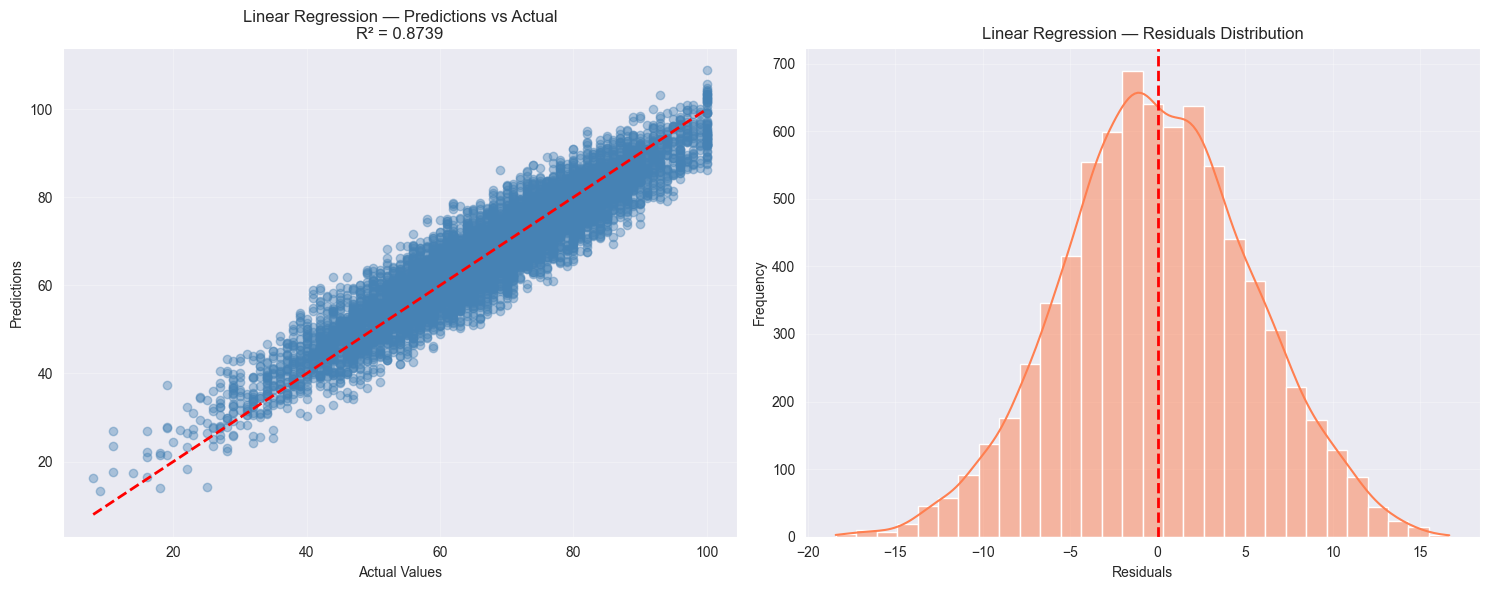

In [5]:
best_base_name = results_df_reg.index[0]
best_base_model = models_reg[best_base_name]
y_pred_base = best_base_model.predict(X_reg_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_reg_test, y_pred_base, alpha=0.4, color='steelblue')
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predictions')
axes[0].set_title(f'{best_base_name} — Predictions vs Actual\nR² = {results_df_reg.loc[best_base_name, "R2"]:.4f}')
axes[0].grid(True, alpha=0.3)

residuals = y_reg_test - y_pred_base
sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color='coral')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_base_name} — Residuals Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.4 Hyperparameter Tuning

In this section we optimize the top 5 models identified in the previous step using **GridSearchCV** with 5-fold cross-validation.

**What are hyperparameters?**
Hyperparameters are configuration settings defined before training that control the learning process — unlike model parameters (weights), they are not learned from data and must be set manually or through systematic search.

**Search strategy — GridSearchCV:**
GridSearchCV exhaustively tests all combinations of hyperparameter values from a predefined grid and selects the combination that maximizes R² on the validation folds.

**Hyperparameters tuned per model:**

| Model | Hyperparameters |
|---|---|
| Random Forest | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf` |
| XGBoost | `n_estimators`, `max_depth`, `learning_rate`, `subsample` |
| CatBoost | `iterations`, `depth`, `learning_rate` |
| EBM | `max_bins`, `interactions` |
| Linear Regression | `fit_intercept` |
| Decision Tree | `max_depth`, `min_samples_split`, `min_samples_leaf` |
| SVR | `C`, `kernel`, `gamma` |
| KNN | `n_neighbors`, `weights`, `metric` |

**Overfitting prevention:**
- `max_depth` limits tree complexity to prevent memorization of training data
- `min_samples_split` and `min_samples_leaf` ensure each node has enough samples to be meaningful
- `subsample` in XGBoost introduces randomness to reduce variance
- Cross-validation ensures the selected hyperparameters generalize across different data subsets

**Scoring metric:** R² — maximizing the proportion of variance explained

> After tuning, all 5 models are re-evaluated on the test set and compared to their base performance to measure the improvement gained from optimization.

In [6]:
param_grids_reg = {
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100, 150],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0]
        }
    },
    'CatBoost': {
        'model': CatBoostRegressor(random_state=42, verbose=0),
        'params': {
            'iterations': [50, 100],
            'depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1]
        }
    },
    'EBM': {
        'model': ExplainableBoostingRegressor(random_state=42),
        'params': {
            'max_bins': [128, 256],
            'interactions': [0, 5, 10]
        }
    },
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {
            'fit_intercept': [True, False]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'params': {
            'n_neighbors': [3, 5, 7, 11, 15],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    }
}

optimized_models_reg = {}
tuned_results_reg = {}

for name in top_5_models_reg:
    grid = GridSearchCV(
        param_grids_reg[name]['model'],
        param_grids_reg[name]['params'],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    grid.fit(X_reg_train_scaled, y_reg_train)
    best = grid.best_estimator_
    optimized_models_reg[name] = best

    y_pred = best.predict(X_reg_test_scaled)

    tuned_results_reg[name] = {
        'Best Params': grid.best_params_,
        'CV R2': round(grid.best_score_, 4),
        'MSE': round(mean_squared_error(y_reg_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_reg_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_reg_test, y_pred)), 4),
        'R2': round(r2_score(y_reg_test, y_pred), 4)
    }

tuned_df_reg = pd.DataFrame(tuned_results_reg).T.sort_values('R2', ascending=False)
display(tuned_df_reg.drop(columns=['Best Params']))

best_reg_name = tuned_df_reg.index[0]
best_reg_model = optimized_models_reg[best_reg_name]

,CV R2,MSE,MAE,RMSE,R2
Linear Regression,0.8752,28.9884,4.3088,5.3841,0.8739
SVR,0.8751,28.9992,4.3094,5.3851,0.8739
EBM,0.8753,29.0817,4.3135,5.3927,0.8735
CatBoost,0.8741,29.2846,4.3208,5.4115,0.8727
XGBoost,0.874,29.2686,4.3236,5.41,0.8727


## 4.5 Learning Curves

Learning curves show how model performance evolves as the size of the training set increases. They are one of the most powerful diagnostic tools for understanding model behavior and generalization.

**How to read a learning curve:**
- The **blue line** represents training score — how well the model fits the data it was trained on
- The **orange line** represents validation score — how well the model generalizes to unseen data
- The **shaded area** represents the standard deviation across the 5 cross-validation folds
- The **x-axis** shows the number of training examples used
- The **y-axis** shows the R² score

**Diagnosing model behavior:**

| Pattern | Diagnosis | Solution |
|---|---|---|
| Training score >> Validation score, large gap | **Overfitting** | Reduce complexity, add regularization, more data |
| Both scores low and close together | **Underfitting** | Increase model complexity, add more features |
| Both scores high and converging as data increases | **Good Fit** | Model is well calibrated |
| Validation score still rising at max training size | **Need more data** | Model would benefit from additional observations |

**What we expect to see for each model:**
- **Linear Regression** — both curves converge quickly and plateau; may underfit if relationship is non-linear
- **Decision Tree** — high training score, lower validation score indicating overfitting tendency
- **Random Forest / XGBoost / CatBoost** — good generalization with smaller train/validation gap
- **EBM** — stable learning curve similar to boosting models

**Scoring metric:** R² — same as used during tuning for consistency

> Learning curves are plotted for all **top 5 tuned models** to compare their learning dynamics and identify any remaining overfitting or underfitting issues after hyperparameter optimization.

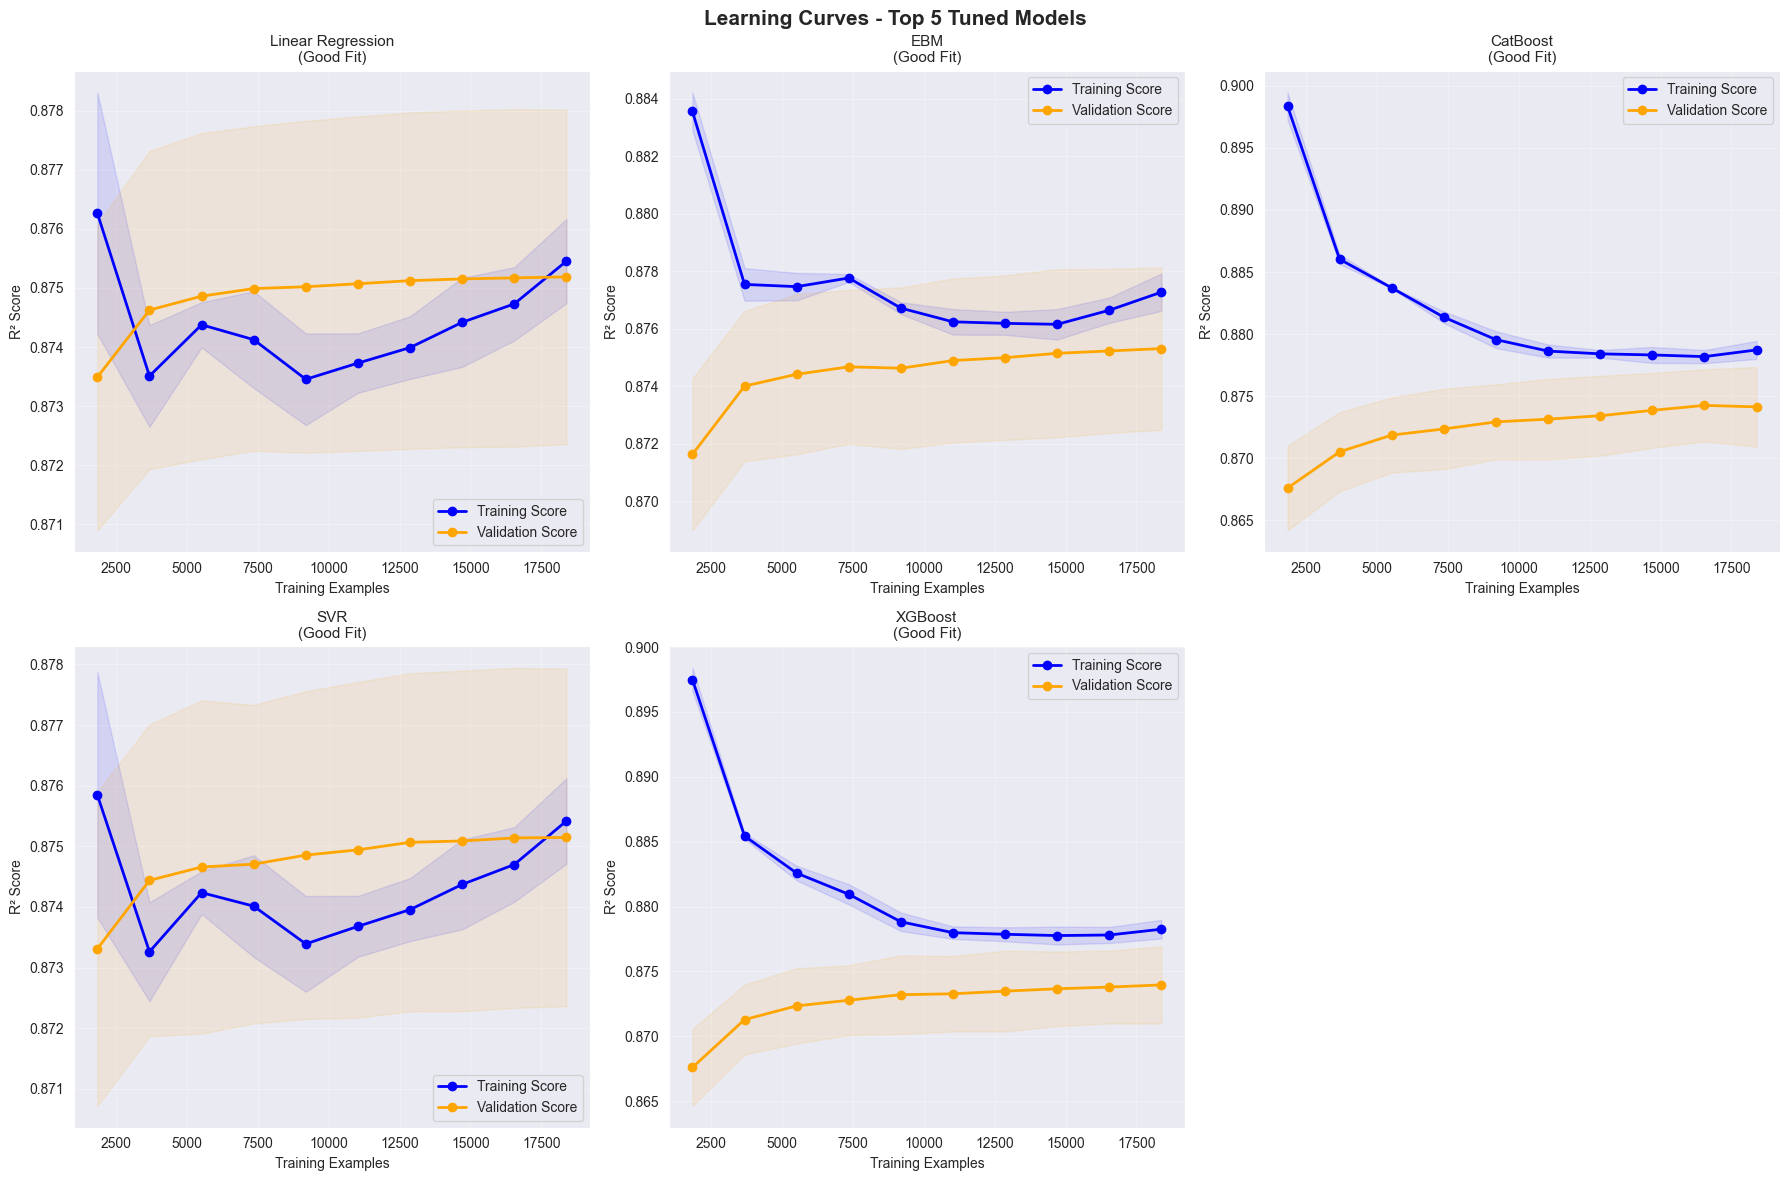

In [7]:
def plot_learning_curve_reg(model, name, X, y, ax, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation Score', linewidth=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')

    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.1:
        status = 'Overfitting'
    elif val_mean[-1] < 0.5:
        status = 'Underfitting'
    else:
        status = 'Good Fit'

    ax.set_title(f'{name}\n({status})', fontsize=11)
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('R² Score')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, name in enumerate(top_5_models_reg):
    plot_learning_curve_reg(optimized_models_reg[name], name, X_reg_train_scaled, y_reg_train, axes[i])

axes[-1].set_visible(False)
plt.suptitle('Learning Curves - Top 5 Tuned Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.6 Explainability — SHAP Analysis

In this section we interpret the predictions of the top 3 tuned models using **SHAP (SHapley Additive exPlanations)**.

**What is SHAP?**
SHAP is a game-theoretic approach to explain the output of any machine learning model. It is based on Shapley values from cooperative game theory — each feature is treated as a "player" and its contribution to the final prediction is calculated by considering all possible combinations of features.

**Why is explainability important here?**
In an educational context, knowing *why* a model predicts a certain math score is just as important as the prediction itself. Educators and administrators need to understand which factors drive academic performance to design effective interventions.

**Types of explanations:**

| Plot | Type | What it shows |
|---|---|---|
| Summary Plot (Beeswarm) | Global | Distribution of SHAP values for all features across all predictions |
| Bar Plot | Global | Mean absolute SHAP value per feature — overall importance ranking |
| Waterfall Plot | Local | Contribution of each feature to a single prediction, starting from the baseline |
| Force Plot | Local | Visual representation of features pushing prediction up or down |
| Scatter Plot | Global | Relationship between feature values and their SHAP impact on MathScore |

**How to interpret SHAP values:**
- A **positive SHAP value** pushes the predicted MathScore **higher**
- A **negative SHAP value** pushes the predicted MathScore **lower**
- Features with **large absolute SHAP values** have the most influence on predictions
- In the beeswarm plot: **red = high feature value**, **blue = low feature value**

**Expected findings:**
- `ReadingScore` and `WritingScore` are expected to dominate as the most important features
- `TestPrep_none` should show negative SHAP values — not completing prep course lowers predicted score
- `LunchType_standard` should show positive SHAP values — standard lunch correlates with higher scores
- `ParentEduc` features should show moderate positive impact for higher education levels

**Top 3 models analyzed:**
For each of the top 3 tuned models we produce:
1. Global summary plot and bar plot — overall feature importance
2. Local waterfall and force plot — explanation for a single student prediction
3. Scatter plots for the 3 most important features — how feature values relate to their SHAP impact

> **Key question:** Which factors most strongly determine a student's predicted math score, and does the model align with our educational domain knowledge?


SHAP Analysis — Linear Regression
TreeExplainer failed: Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._base.LinearRegression'>
Falling back to KernelExplainer...


100%|██████████| 50/50 [00:01<00:00, 29.74it/s]


Using KernelExplainer with 50 samples (DataFrame mode)
SHAP values shape: (50, 14)
Features shape: (50, 14)


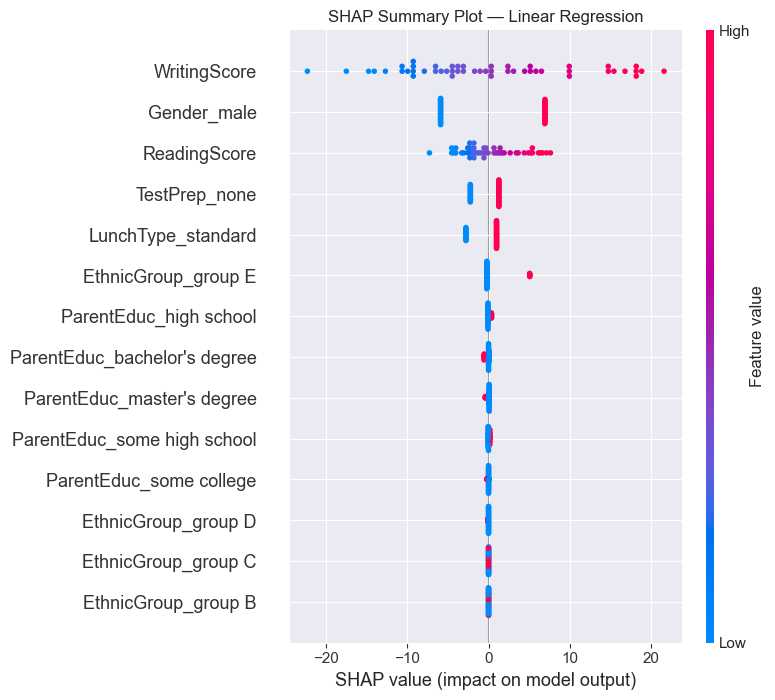

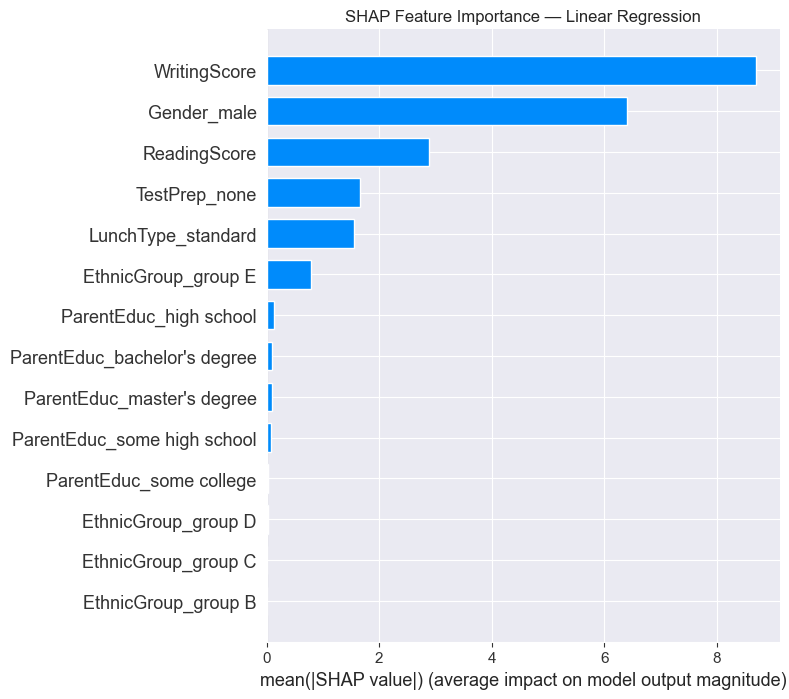

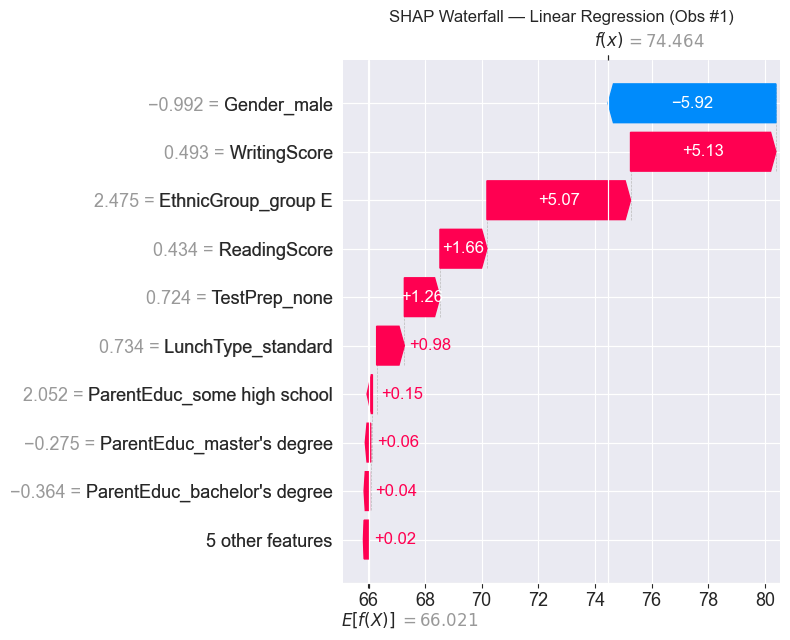

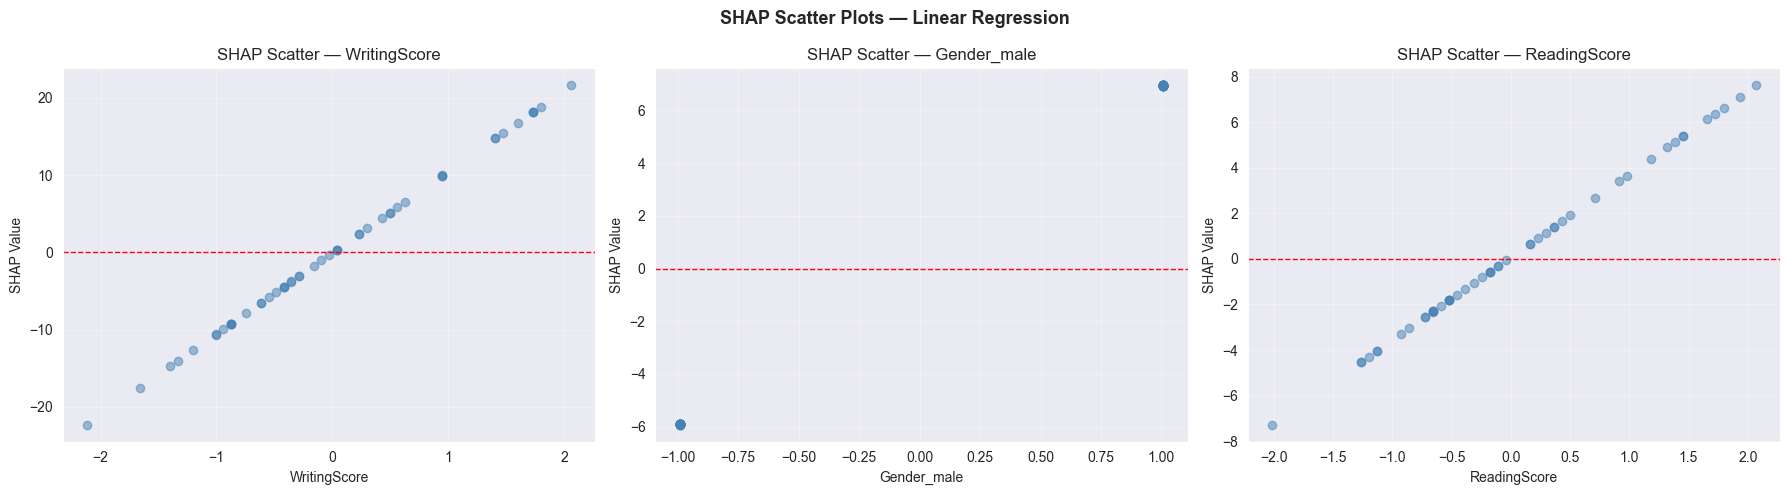

Top 3 most important features: ['WritingScore', 'Gender_male', 'ReadingScore']


SHAP Analysis — EBM
TreeExplainer failed: Model type not yet supported by TreeExplainer: <class 'interpret.glassbox._ebm._ebm.ExplainableBoostingRegressor'>
Falling back to KernelExplainer...


100%|██████████| 50/50 [00:02<00:00, 23.48it/s]


Using KernelExplainer with 50 samples (DataFrame mode)
SHAP values shape: (50, 14)
Features shape: (50, 14)


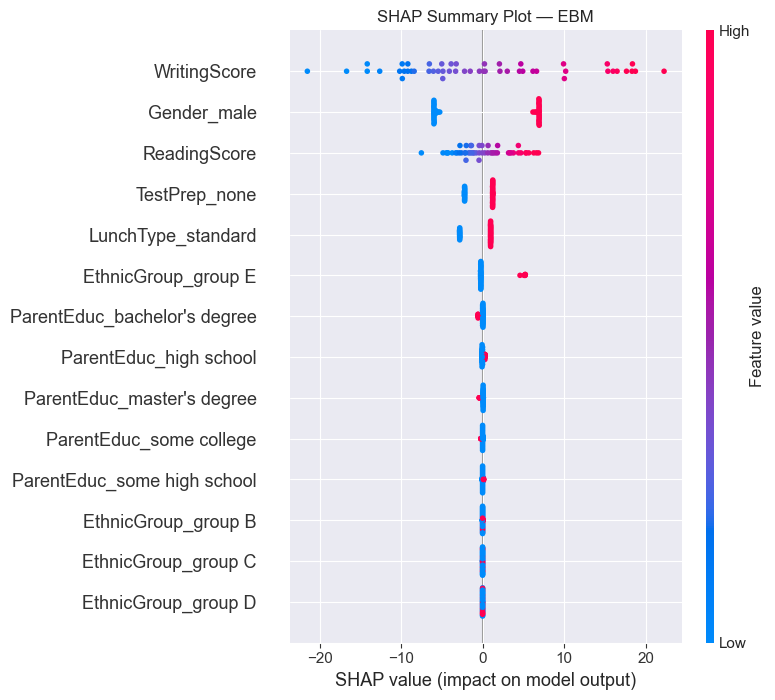

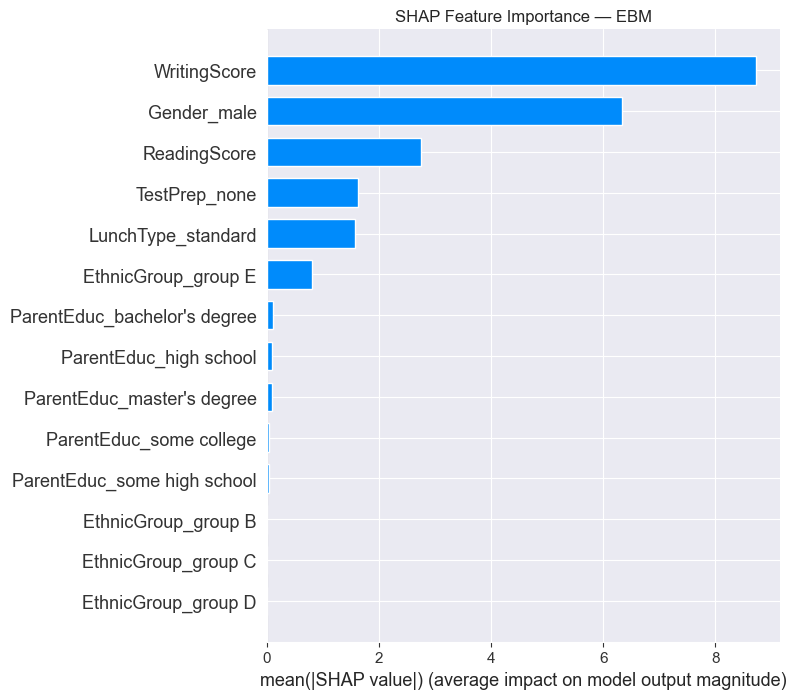

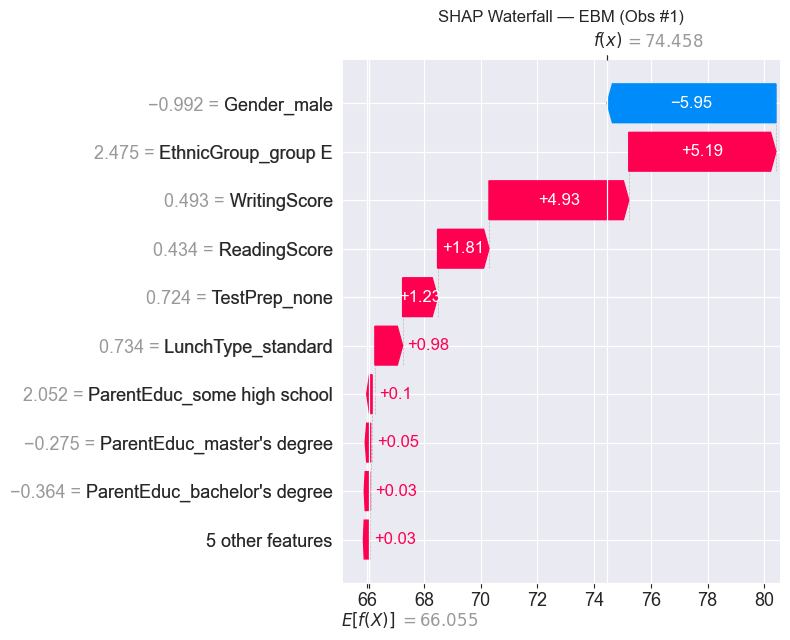

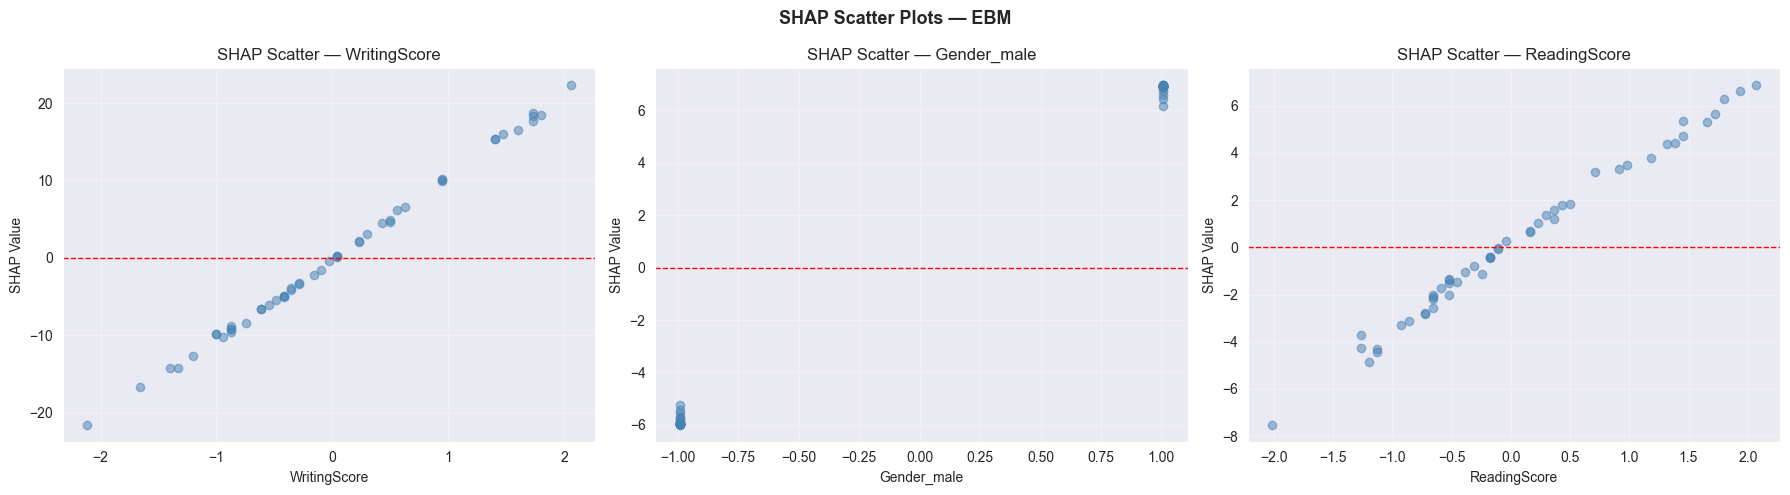

Top 3 most important features: ['WritingScore', 'Gender_male', 'ReadingScore']


SHAP Analysis — CatBoost
Using TreeExplainer with 100 samples
SHAP values shape: (100, 14)
Features shape: (100, 14)


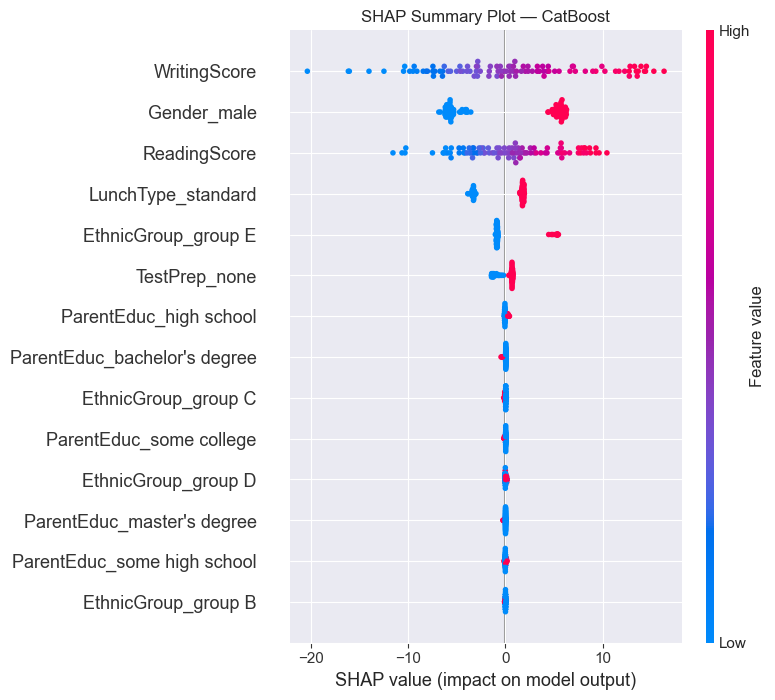

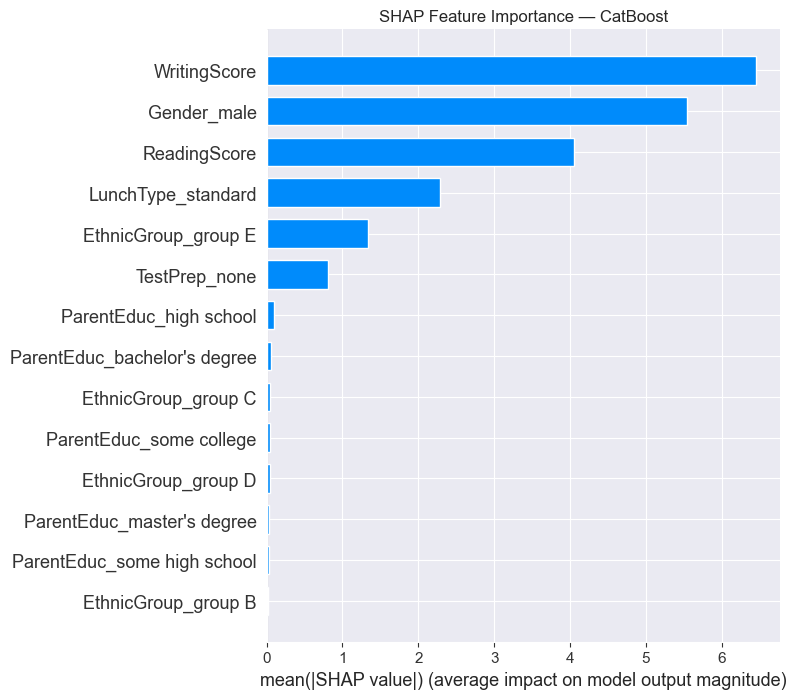

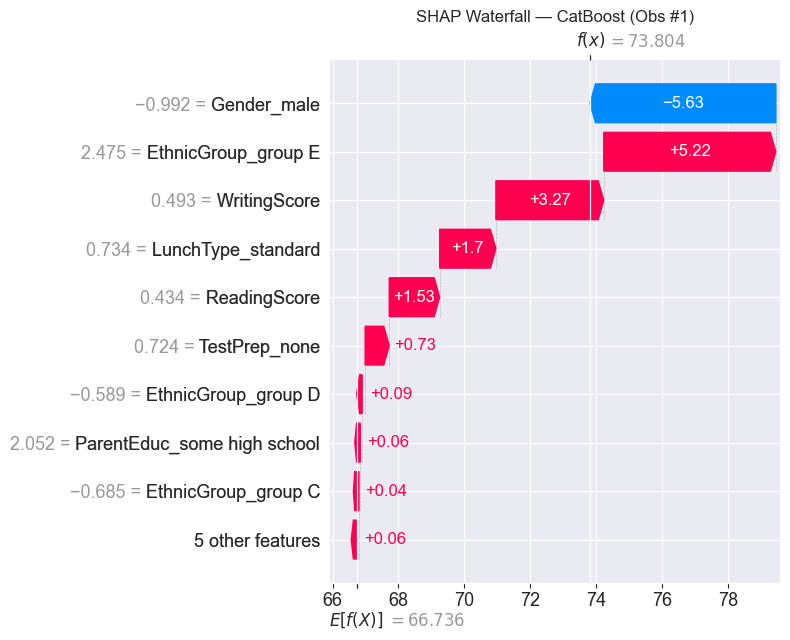

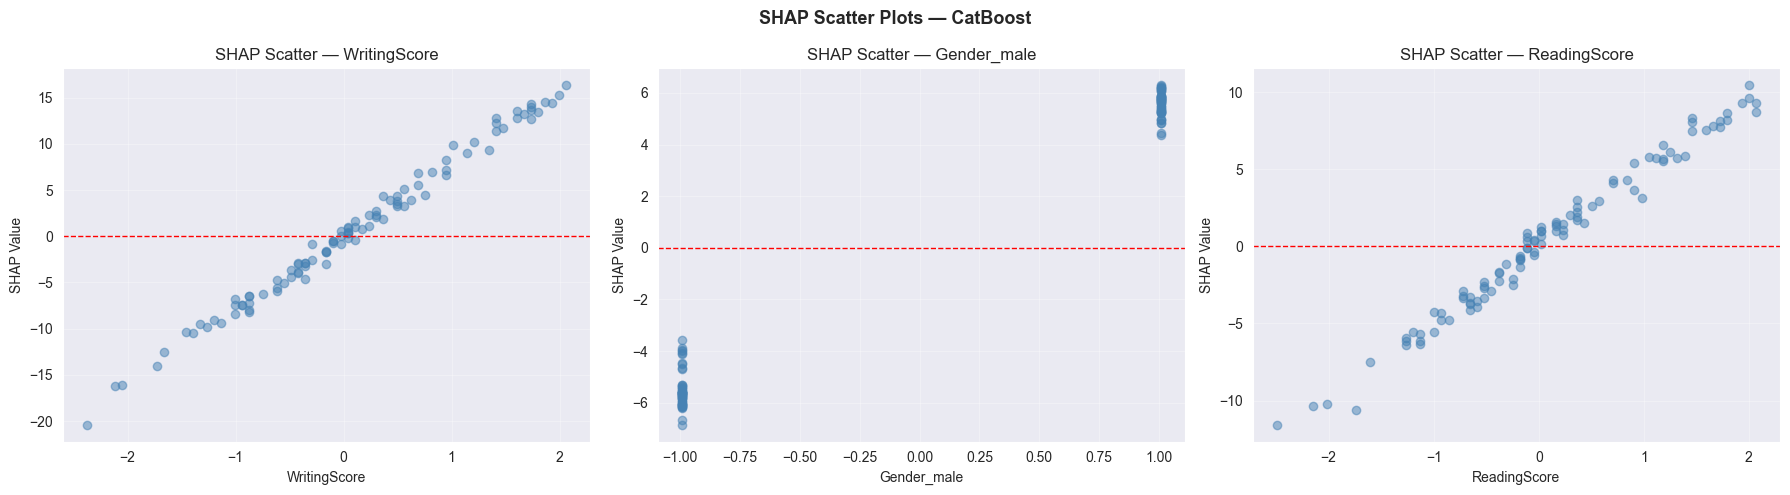

Top 3 most important features: ['WritingScore', 'Gender_male', 'ReadingScore']



In [8]:
top3_reg = list(optimized_models_reg.keys())[:3]

for model_name in top3_reg:
    model = optimized_models_reg[model_name]
    print(f'\n{"="*50}')
    print(f'SHAP Analysis — {model_name}')
    print(f'{"="*50}')

    n_samples = 100

    try:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_reg_test_scaled[:n_samples])
        ev = explainer.expected_value
        X_used = X_reg_test_scaled[:n_samples]
        print(f"Using TreeExplainer with {n_samples} samples")
    except Exception as e:
        print(f"TreeExplainer failed: {e}")
        print("Falling back to KernelExplainer...")

        n_samples_shap = 50

        background = shap.sample(pd.DataFrame(X_reg_train_scaled, columns=X_reg.columns), 50)

        def predict_fn(X):
            if isinstance(X, np.ndarray):
                X = pd.DataFrame(X, columns=X_reg.columns)
            return model.predict(X)

        try:
            explainer = shap.KernelExplainer(predict_fn, background)
            X_test_df = pd.DataFrame(X_reg_test_scaled[:n_samples_shap], columns=X_reg.columns)
            sv = explainer.shap_values(X_test_df)
            ev = explainer.expected_value
            X_used = X_test_df
            print(f"Using KernelExplainer with {n_samples_shap} samples (DataFrame mode)")
        except Exception as e2:
            print(f"KernelExplainer with DataFrame failed: {e2}")
            background = shap.sample(X_reg_train_scaled, 50)
            explainer = shap.KernelExplainer(model.predict, background)
            sv = explainer.shap_values(X_reg_test_scaled[:n_samples_shap])
            ev = explainer.expected_value
            X_used = X_reg_test_scaled[:n_samples_shap]
            print(f"Using KernelExplainer with {n_samples_shap} samples (array mode)")

        n_samples = n_samples_shap

    print(f"SHAP values shape: {sv.shape}")
    print(f"Features shape: {X_used.shape}")

    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_used, show=False)
    plt.title(f'SHAP Summary Plot — {model_name}')
    plt.tight_layout()
    plt.show()

    # Bar plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_used, plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance — {model_name}')
    plt.tight_layout()
    plt.show()

    # Waterfall plot
    try:
        if hasattr(X_used, 'iloc'):
            data_first = X_used.iloc[0].values
            feature_names = X_used.columns.tolist()
        else:
            data_first = X_used[0]
            feature_names = X_reg.columns.tolist()

        exp = shap.Explanation(
            values=sv[0] if len(sv.shape) == 2 else sv[0],
            base_values=ev,
            data=data_first,
            feature_names=feature_names
        )
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(exp, show=False)
        plt.title(f'SHAP Waterfall — {model_name} (Obs #1)')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Waterfall plot error: {e}")

    # Force plot
    try:
        shap.initjs()
        if hasattr(X_used, 'iloc'):
            data_force = X_used.iloc[0]
            feature_names_force = X_used.columns.tolist()
        else:
            data_force = X_used[0]
            feature_names_force = X_reg.columns.tolist()

        display(shap.force_plot(ev, sv[0] if len(sv.shape) == 2 else sv[0],
                                data_force,
                                feature_names=feature_names_force))
    except Exception as e:
        print(f"Force plot error: {e}")

    # Scatter plots top 3 features
    mean_abs = np.abs(sv).mean(axis=0)
    top3_idx = np.argsort(mean_abs)[::-1][:3]
    top3_feat = X_reg.columns[top3_idx].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, idx in enumerate(top3_idx):
        if hasattr(X_used, 'iloc'):
            x_data = X_used.iloc[:, idx]
        else:
            x_data = X_used[:, idx]

        axes[i].scatter(x_data, sv[:, idx], alpha=0.5, color='steelblue')
        axes[i].axhline(0, color='red', linestyle='--', linewidth=1)
        axes[i].set_xlabel(X_reg.columns[idx])
        axes[i].set_ylabel('SHAP Value')
        axes[i].set_title(f'SHAP Scatter — {X_reg.columns[idx]}')
        axes[i].grid(True, alpha=0.3)
    plt.suptitle(f'SHAP Scatter Plots — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Top 3 most important features: {top3_feat}')
    print(f'{"="*50}\n')